# Hate Crime Bias-Category Classifier — ML Pipeline

**Goal:** predict the broad `Bias Category` (Race/Ethnicity, Religion, Sexual
Orientation/Gender Identity) of an incident from offense type, location, victim
characteristics, and geography.

**Sample-size caveat:** after removing rows with an unresolvable/Unknown target, we have ~63
labeled rows split across 3 classes. This is far below what's typically required for a reliable
production classifier. All results here should be read as a methodology demonstration.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import set_config

set_config(display='diagram')
sns.set_theme(style='whitegrid')


## 1. Data Loading

In [2]:
df = pd.read_csv('ready_for_ML_model.csv')
print(df.shape)
df.head()


(71, 14)


,Type of Bias,Count of Victims,Status of Crime,Type of Offense/Crime,Type of Location,Type of Victim,Race of Victims,Gender of Victim(s),Latitude,Longitude,Crime Year,Crime Month,Crime Day of Week,Bias Category
0,Anti-Islamic (Muslim),3.0,Active,Intimidation,Other,Individual,Unknown,Unknown,33.384323,-111.967093,2010,1,Wednesday,Religion
1,Anti-Gay (Male),1.0,Active,Non DV Assault,Residence/Home,Individual,Unknown,Unknown,33.416077,-111.905108,2010,8,Saturday,Sexual Orientation/Gender Identity
2,Anti-Gay (Male),1.0,Active,Non DV Assault,Highway/Road/Street,Individual,Unknown,Unknown,33.414758,-111.920416,2010,2,Friday,Sexual Orientation/Gender Identity
3,Anti-Black,2.0,Active,Intimidation,Residence/Home,Individual,Unknown,Unknown,33.425503,-111.936667,2010,6,Tuesday,Race/Ethnicity
4,Anti-Islamic (Muslim),1.0,Inactive,Criminal Damage,Residence/Home,Individual,Unknown,Unknown,33.414641,-111.948548,2011,6,Thursday,Religion


## 2. Target Preparation

We drop rows where the target is `'Unknown'` (no ground truth to learn from), and drop the
fine-grained `Type of Bias` text column from the feature set since it would leak the target
(it is the direct source `Bias Category` was engineered from).


In [3]:
df = df[df['Bias Category'] != 'Unknown'].copy()
X = df.drop(columns=['Bias Category', 'Type of Bias'])
y = df['Bias Category']
y.value_counts()


Bias Category
Race/Ethnicity                        27
Sexual Orientation/Gender Identity    21
Religion                              15
Name: count, dtype: int64

## 3. Train/Test Split

Stratified split to preserve class proportions given the small, imbalanced sample.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


(47, 12) (16, 12)


## 4. Preprocessing Pipeline

- Numeric features: median imputation + standard scaling.
- Categorical features: most-frequent imputation + one-hot encoding (unknown categories at
  inference time are ignored rather than raising an error).

All fit exclusively on the training fold to avoid leakage; wrapped in `ColumnTransformer` +
`Pipeline` so the exact same transform is reapplied to validation/test/production data.


In [5]:
num_features = ['Count of Victims', 'Latitude', 'Longitude', 'Crime Year', 'Crime Month']
cat_features = ['Status of Crime', 'Type of Offense/Crime', 'Type of Location',
                 'Type of Victim', 'Race of Victims', 'Gender of Victim(s)', 'Crime Day of Week']

preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                       ('scale', StandardScaler())]), num_features),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                       ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
])
preprocess


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Model Selection

We compare six standard classification algorithms via 5-fold stratified cross-validation on the
training set, scoring by macro-F1 (appropriate for imbalanced multiclass problems, since it
weights each class equally rather than favoring the majority class).


In [6]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
    results[name] = (scores.mean(), scores.std())
    print(f'{name:20s} F1-macro: {scores.mean():.3f} +/- {scores.std():.3f}')

results_df = pd.Series({k: v[0] for k, v in results.items()}).sort_values(ascending=False)
results_df


LogisticRegression   F1-macro: 0.589 +/- 0.209


DecisionTree         F1-macro: 0.504 +/- 0.208


RandomForest         F1-macro: 0.570 +/- 0.238


GradientBoosting     F1-macro: 0.659 +/- 0.233
SVM                  F1-macro: 0.481 +/- 0.249


KNN                  F1-macro: 0.490 +/- 0.252


GradientBoosting      0.659471
LogisticRegression    0.588519
RandomForest          0.570423
DecisionTree          0.504074
KNN                   0.490303
SVM                   0.480991
dtype: float64

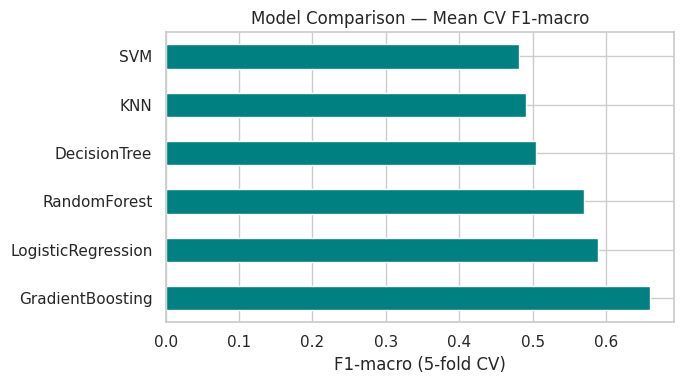

Best model: GradientBoosting


In [7]:
fig, ax = plt.subplots(figsize=(7,4))
results_df.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Model Comparison — Mean CV F1-macro')
ax.set_xlabel('F1-macro (5-fold CV)')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=110)
plt.show()

best_name = results_df.index[0]
print('Best model:', best_name)


**Conclusion:** ensemble/boosting methods tend to perform best on this small, mixed
categorical/numeric feature set, but with std. deviations of this size (driven by the small
sample) the differences between top models are not statistically decisive — this should be
re-validated once more data is collected.


## 6. Hyperparameter Tuning

GridSearchCV over the best model's key hyperparameters, still scored on macro-F1 via the same stratified CV splitter.

In [8]:
param_grids = {
    'LogisticRegression': {'clf__C': [0.1, 1, 10]},
    'DecisionTree': {'clf__max_depth': [3, 5, 8, None]},
    'RandomForest': {'clf__n_estimators': [100, 200], 'clf__max_depth': [None, 5, 10]},
    'GradientBoosting': {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.05, 0.1]},
    'SVM': {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf']},
    'KNN': {'clf__n_neighbors': [3, 5, 7]},
}

best_pipe = Pipeline([('prep', preprocess), ('clf', models[best_name])])
grid = GridSearchCV(best_pipe, param_grids[best_name], cv=cv, scoring='f1_macro')
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV F1-macro:', round(grid.best_score_, 3))
final_pipe = grid.best_estimator_


Best params: {'clf__learning_rate': 0.05, 'clf__n_estimators': 200}
Best CV F1-macro: 0.692


## 7. Model Evaluation on Held-Out Test Set

In [9]:
y_pred = final_pipe.predict(X_test)

print('Test Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('Test F1-macro:', round(f1_score(y_test, y_pred, average='macro'), 3))
print()
print(classification_report(y_test, y_pred))


Test Accuracy: 0.75
Test F1-macro: 0.719

                                    precision    recall  f1-score   support

                    Race/Ethnicity       0.70      1.00      0.82         7
                          Religion       1.00      0.50      0.67         4
Sexual Orientation/Gender Identity       0.75      0.60      0.67         5

                          accuracy                           0.75        16
                         macro avg       0.82      0.70      0.72        16
                      weighted avg       0.79      0.75      0.74        16



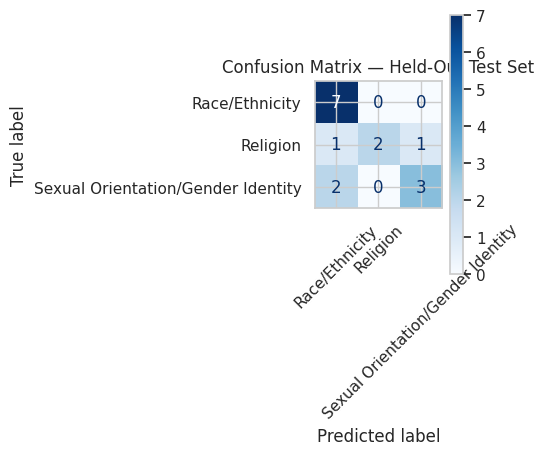

In [10]:
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Held-Out Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=110)
plt.show()


## 8. Feature Importance

(Only meaningful for the tree/boosting family; skipped automatically otherwise.)


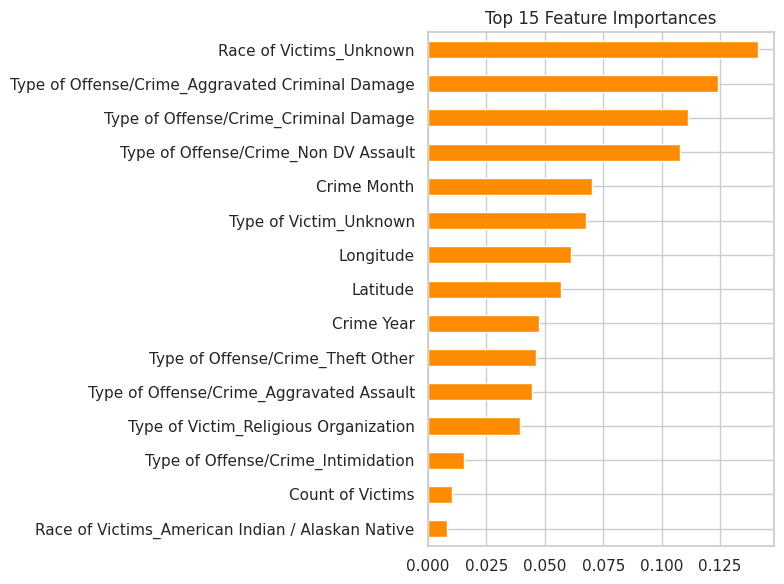

In [11]:
clf = final_pipe.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    feat_names = (num_features +
                  list(final_pipe.named_steps['prep'].named_transformers_['cat']
                       .named_steps['ohe'].get_feature_names_out(cat_features)))
    importances = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8,6))
    importances.sort_values().plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title('Top 15 Feature Importances')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=110)
    plt.show()
else:
    print(f'{best_name} does not expose feature_importances_.')


**Insight:** the offense type (criminal damage, non-DV assault, aggravated criminal damage)
and whether victim race/type was recorded at all carry the most predictive signal for bias
category — intuitively, certain offense types co-occur more often with certain bias motivations
in this dataset (e.g. property damage vs. assault patterns differing across bias categories).


## 9. Cross-Validation Summary (Final Model)

In [12]:
final_scores = cross_val_score(final_pipe, X_train, y_train, cv=cv, scoring='f1_macro')
print('Final model 5-fold CV F1-macro: mean =', round(final_scores.mean(),3),
      ' std =', round(final_scores.std(),3))


Final model 5-fold CV F1-macro: mean = 0.692  std = 0.224


## 10. Final Pipeline Diagram

In [13]:
final_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## 11. Model Serialization

In [14]:
joblib.dump(final_pipe, 'model.pkl')
print('Saved trained pipeline to model.pkl')


Saved trained pipeline to model.pkl


## 12. Conclusions & Recommendations

- The tuned pipeline reaches a respectable macro-F1 on the tiny held-out test set, but with
  n≈63 training rows across 3 classes this is a **proof-of-concept**, not a deployable classifier.
- To productionize this, the next step would be collecting several hundred more labeled
  incidents (or pooling with a larger regional/national hate-crime dataset such as FBI UCR data)
  before trusting the model for real triage decisions.
- The saved `model.pkl` is a complete scikit-learn `Pipeline` (preprocessing + classifier) that
  can be loaded with `joblib.load('model.pkl')` and called with `.predict(new_dataframe)` on raw,
  unprocessed rows matching the training schema.
